In [ ]:
import pandas as pd
import numpy as np  # For mathematical calculations
import seaborn as sns # For data visualization
import matplotlib.pyplot as plt # For plotting graphs
%matplotlib inline
import warnings # To ignore any warnings warnings.filterwarnings("ignore")

In [ ]:
train = pd.read_csv('/content/train_ctrUa4K (1).csv')
test = pd.read_csv('/content/test_lAUu6dG (1).csv')

In [ ]:
train_original = train.copy()
test_original = test.copy()

In [ ]:
train

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


#Hypothesis

* Salary: Applicants with high income should have more chances of loan approval.
* Previous history: Applicants who have repayed their previous debts should have higher chances of loan approval.
* Loan amount: Loan approval should also depend on the loan amount. If the loan amount is less, chances of loan approval should be high.
* Loan term: Loan for less time period and less amount should have higher chances of approval.
* EMI: Lesser the amount to be paid monthly to repay the loan, higher the chances of loan approval.








#EDA

In [ ]:
train['Loan_Status'].value_counts()

,count
Loan_Status,
Y,422
N,192


Data set is not balanced with respect to Target variable

In [ ]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
train.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


from this we can see that credit history is categorical in nature

From this we can see that Credit

In [ ]:
train.describe(include = 'object')

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,Property_Area,Loan_Status
count,614,601,611,599,614,582,614,614
unique,614,2,2,4,2,2,3,2
top,LP002990,Male,Yes,0,Graduate,No,Semiurban,Y
freq,1,489,398,345,480,500,233,422


Descriptive statistics for numerical columns:
       ApplicantIncome  CoapplicantIncome  LoanAmount  Loan_Amount_Term  \
count       614.000000         614.000000  592.000000         600.00000   
mean       5403.459283        1621.245798  146.412162         342.00000   
std        6109.041673        2926.248369   85.587325          65.12041   
min         150.000000           0.000000    9.000000          12.00000   
25%        2877.500000           0.000000  100.000000         360.00000   
50%        3812.500000        1188.500000  128.000000         360.00000   
75%        5795.000000        2297.250000  168.000000         360.00000   
max       81000.000000       41667.000000  700.000000         480.00000   

       Credit_History  
count      564.000000  
mean         0.842199  
std          0.364878  
min          0.000000  
25%          1.000000  
50%          1.000000  
75%          1.000000  
max          1.000000  


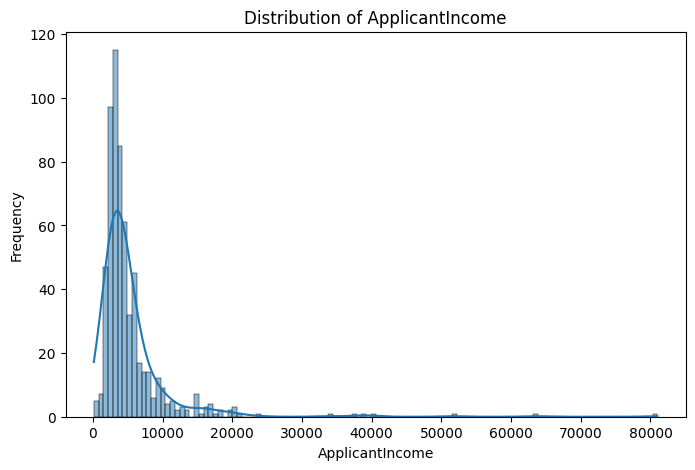

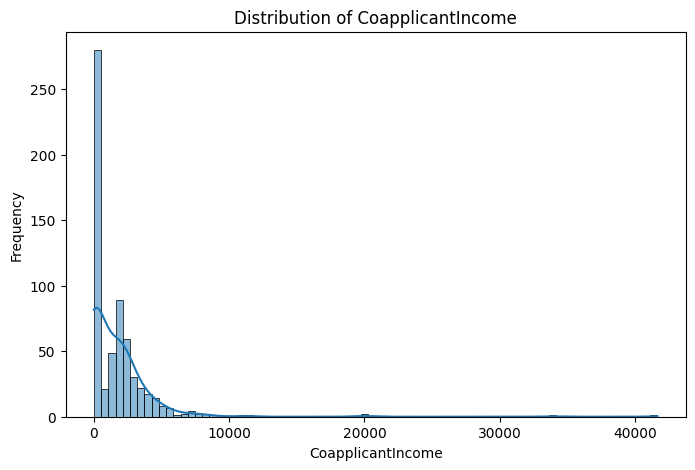

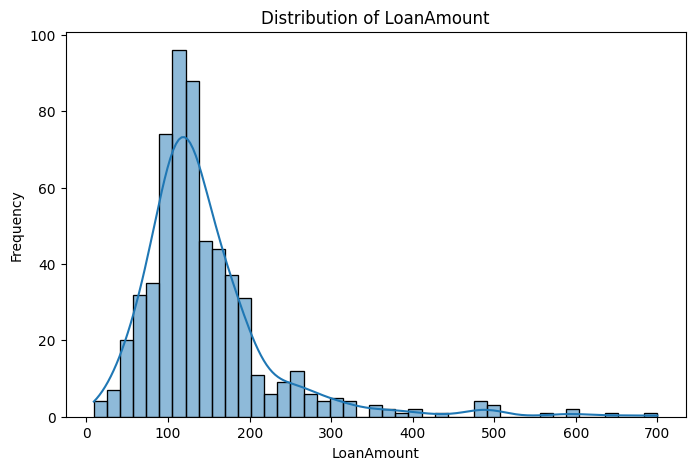

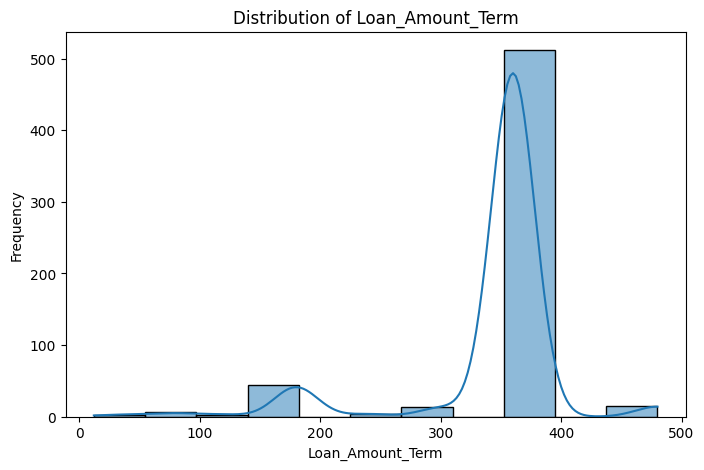

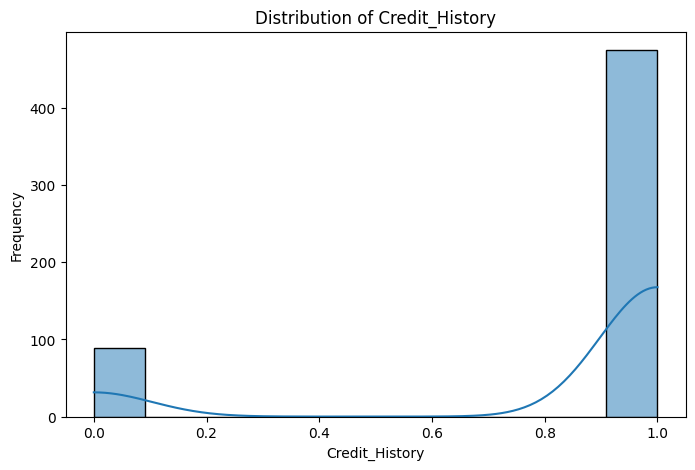

In [ ]:
numerical_cols = train.select_dtypes(include=np.number).columns
print("Descriptive statistics for numerical columns:")
print(train[numerical_cols].describe())

for col in numerical_cols:
    plt.figure(figsize=(8, 5))
    sns.histplot(train[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.show()

We can clearly see that credit history and Loan_term_amount looks like categorical in nature,
Applicant income is right skewed,
Loan Amount also right skewed,
For coapplicant income only high peak happens at 0.

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


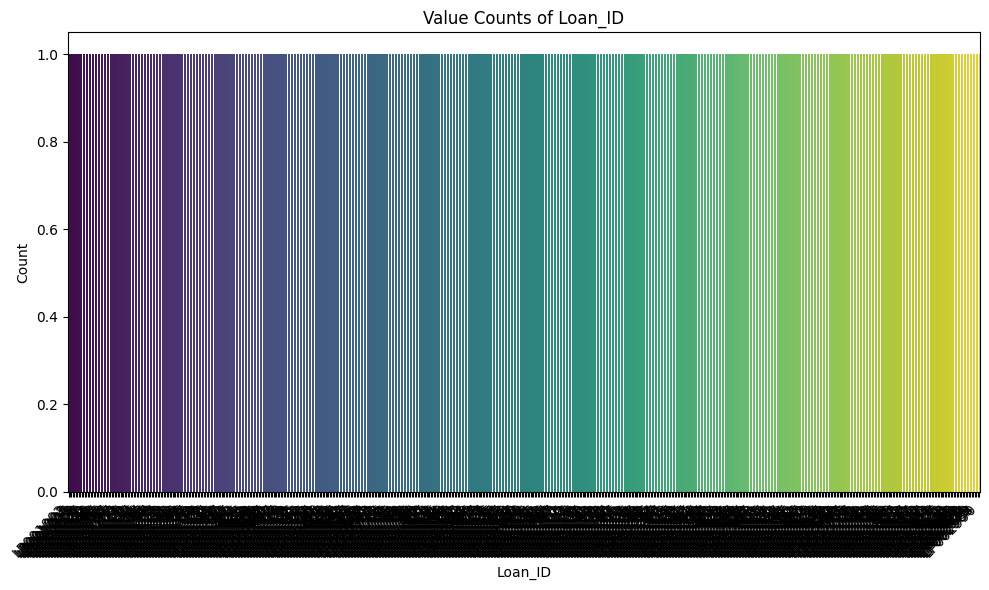

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


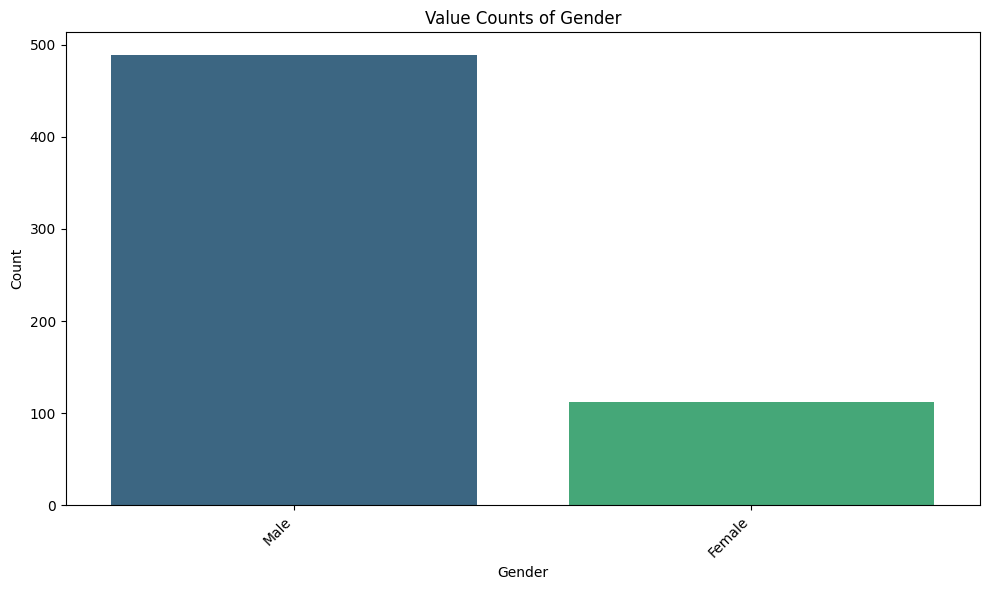

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


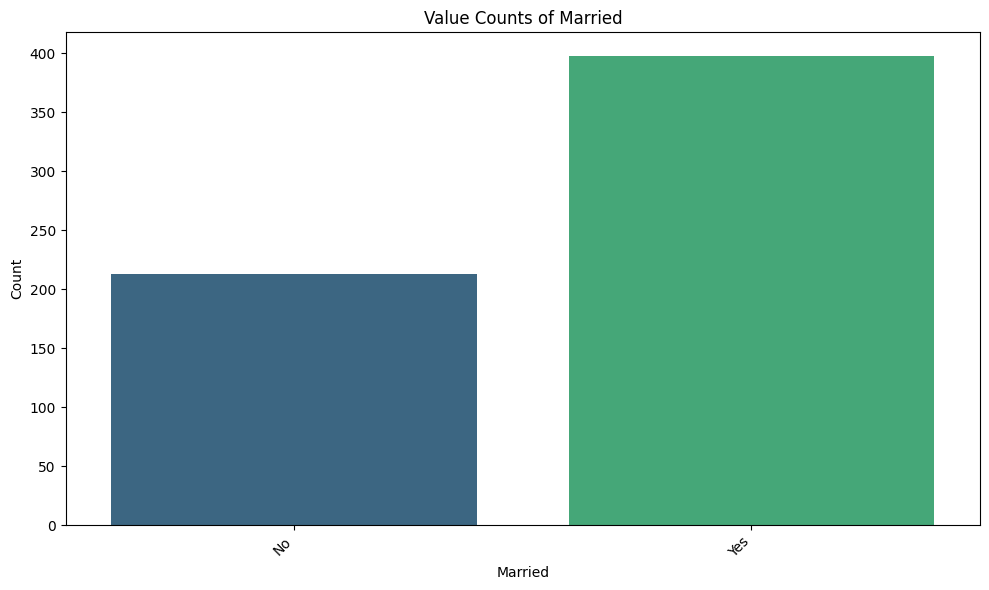

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


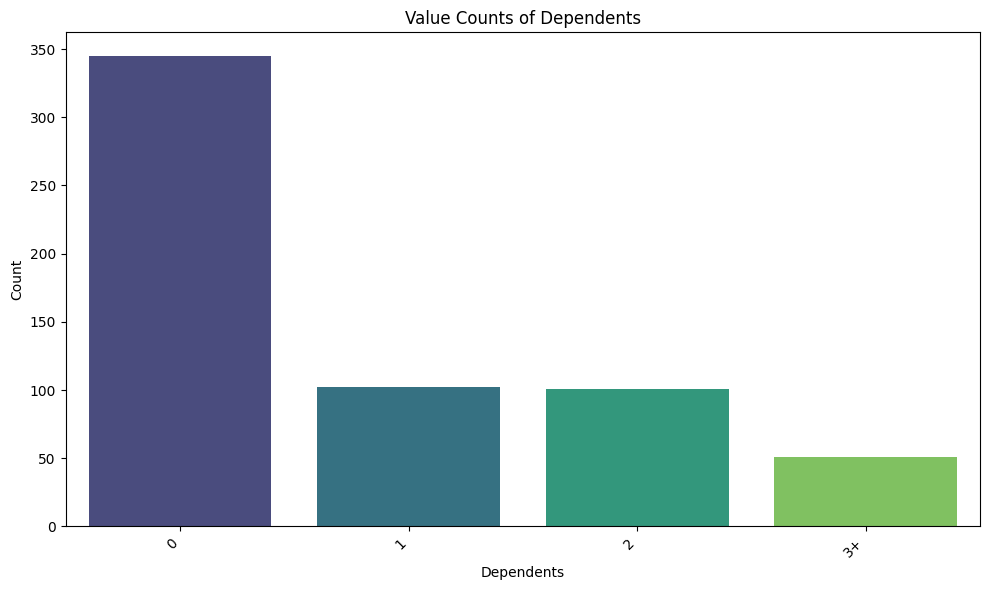

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


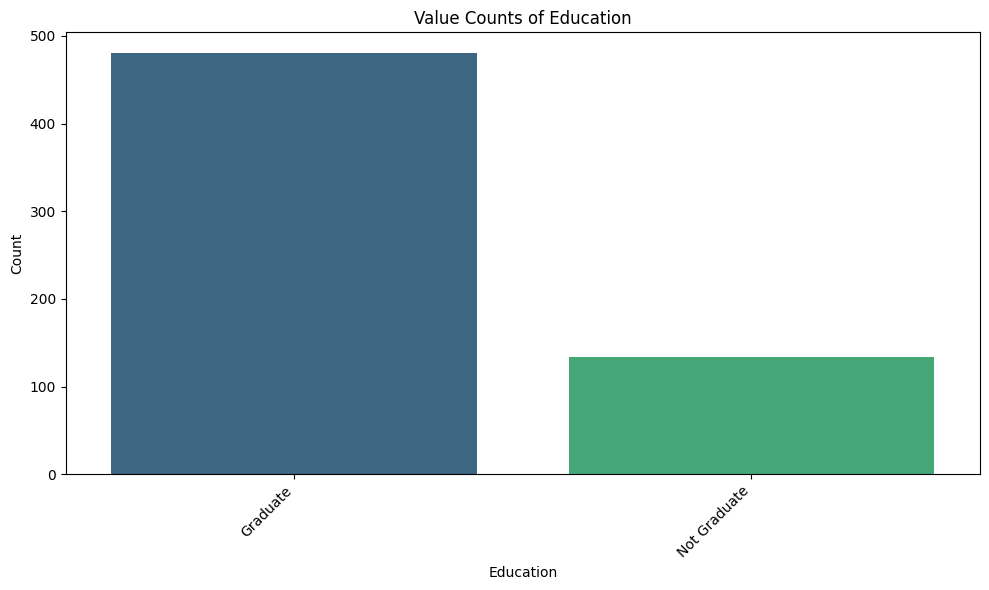

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


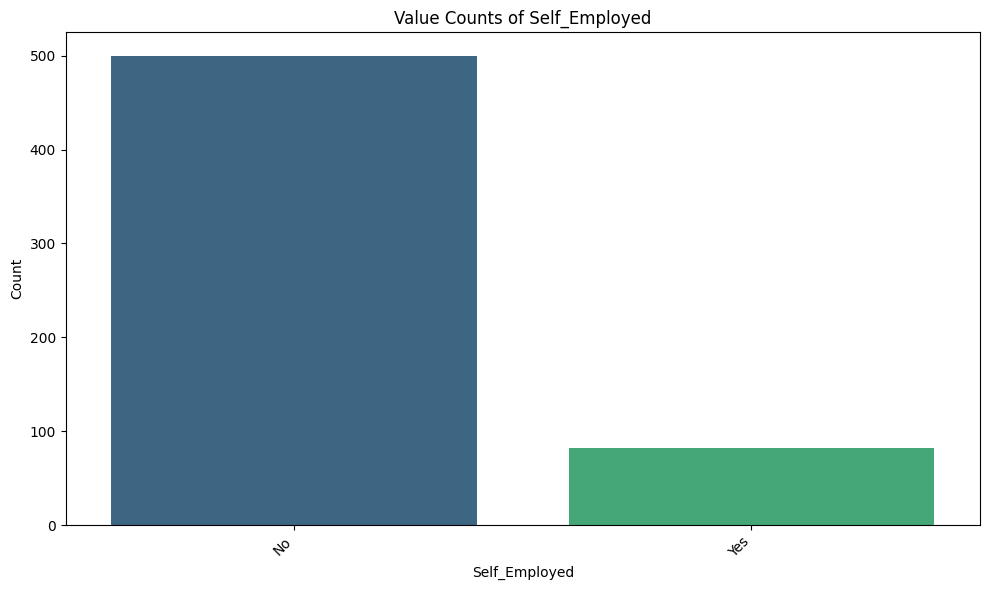

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


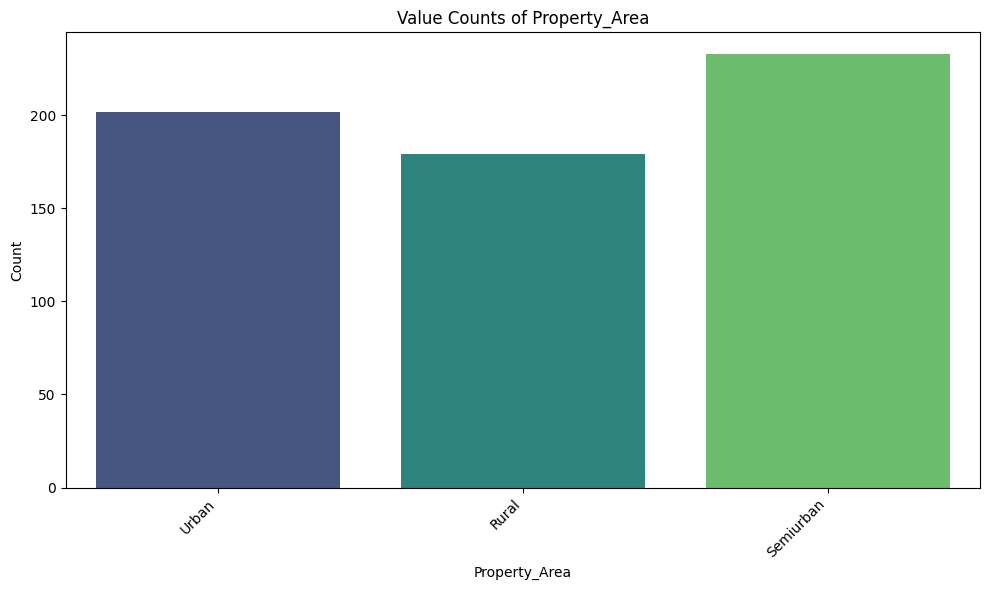

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


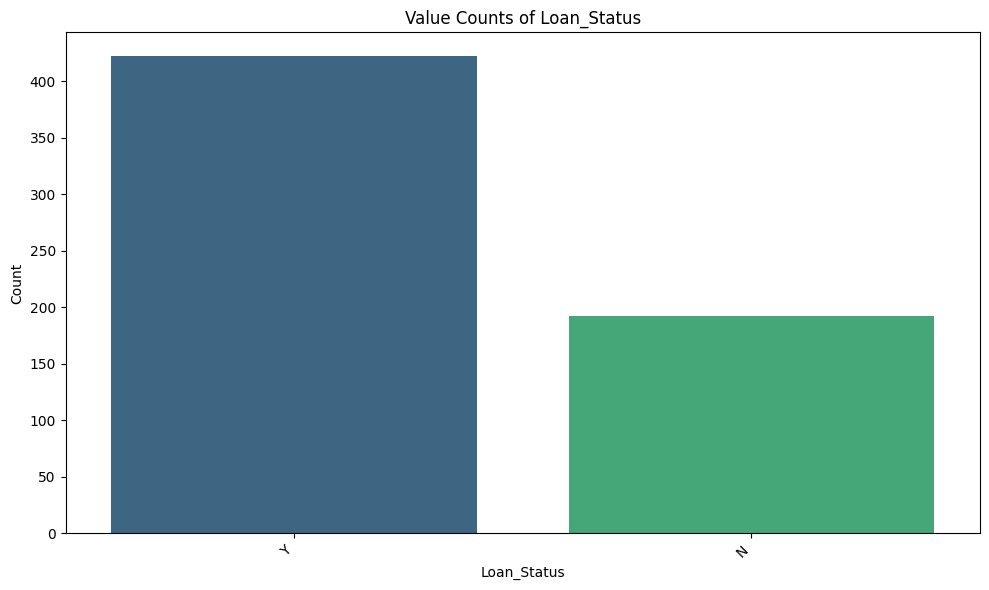

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


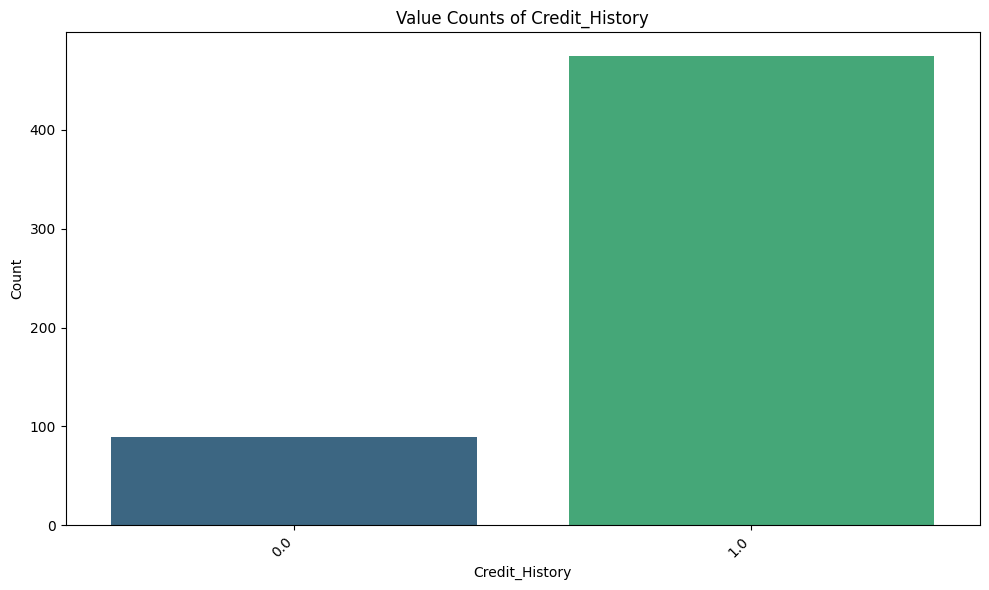

/tmp/ipykernel_674/2045365453.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=col, data=train, palette='viridis')


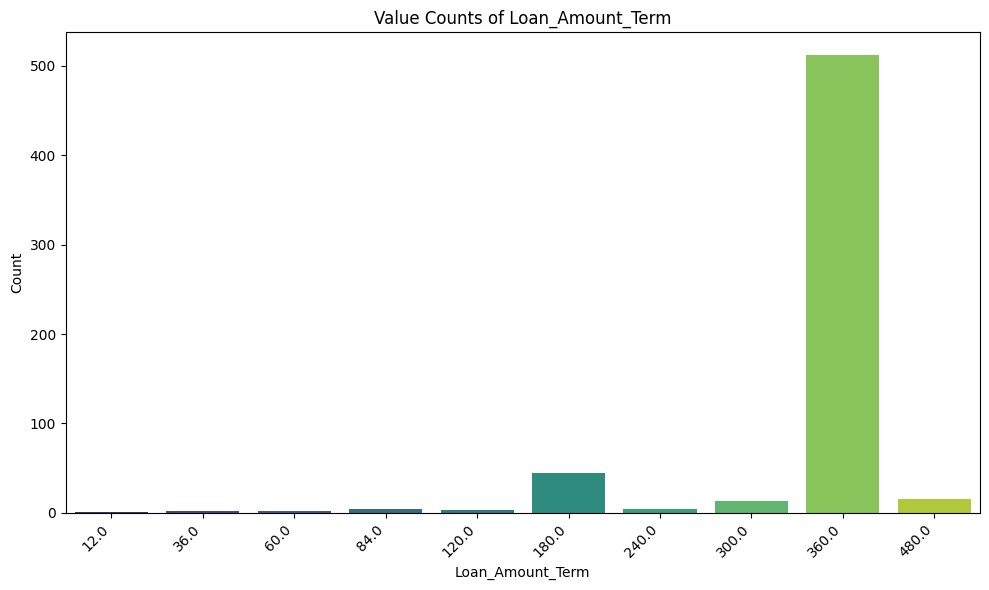

In [ ]:
categorical_cols = train.select_dtypes(include='object').columns.tolist()

# Add 'Credit_History' and 'Loan_Amount_Term' as requested, even if they were detected as numerical previously
if 'Credit_History' not in categorical_cols:
    categorical_cols.append('Credit_History')
if 'Loan_Amount_Term' not in categorical_cols:
    categorical_cols.append('Loan_Amount_Term')

for col in categorical_cols:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, data=train, palette='viridis')
    plt.title(f'Value Counts of {col}')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

*   more male people applied for loan
*   more married people applied for loan
*   With 0 dependent people applied for loan more
*   Graduate people applied for loan more
*   Self employeed people applied less loan compare to non self employee
*   Semi urban people applied more loan
*   credit history with paid loan has more loan application
*   360 days term loan is more common











--- Categorical Features vs. Loan_Status ---



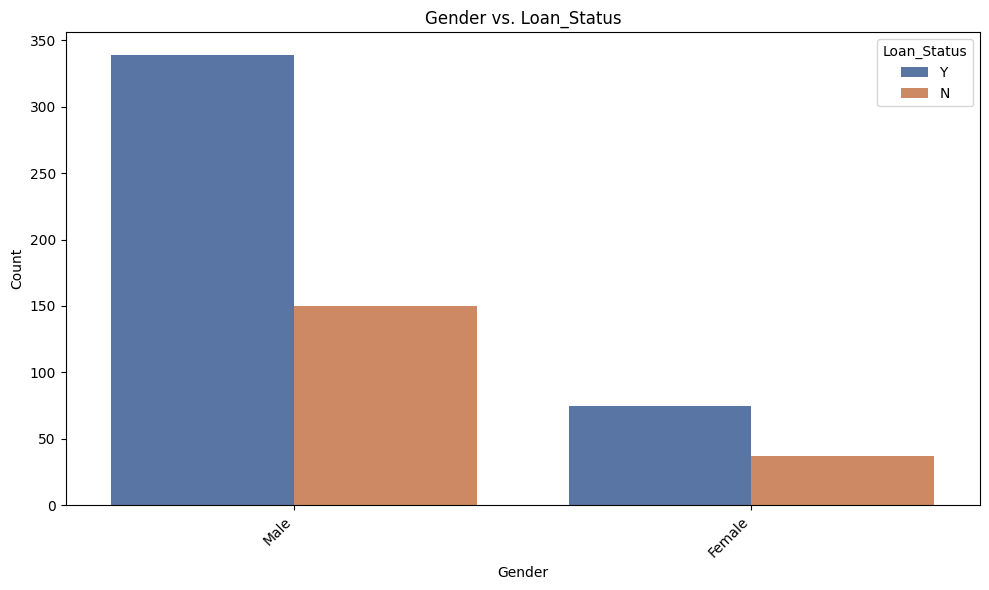

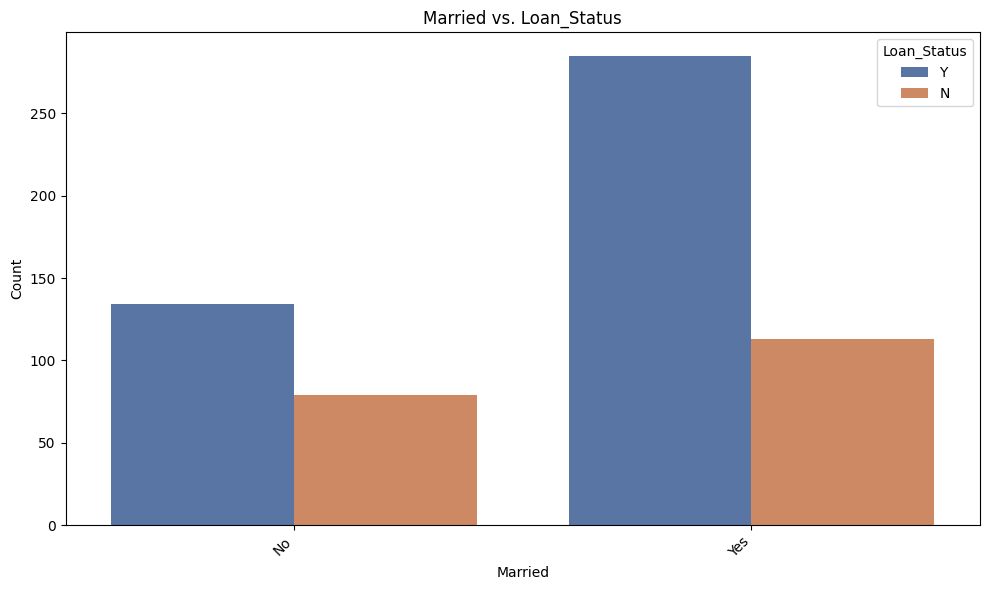

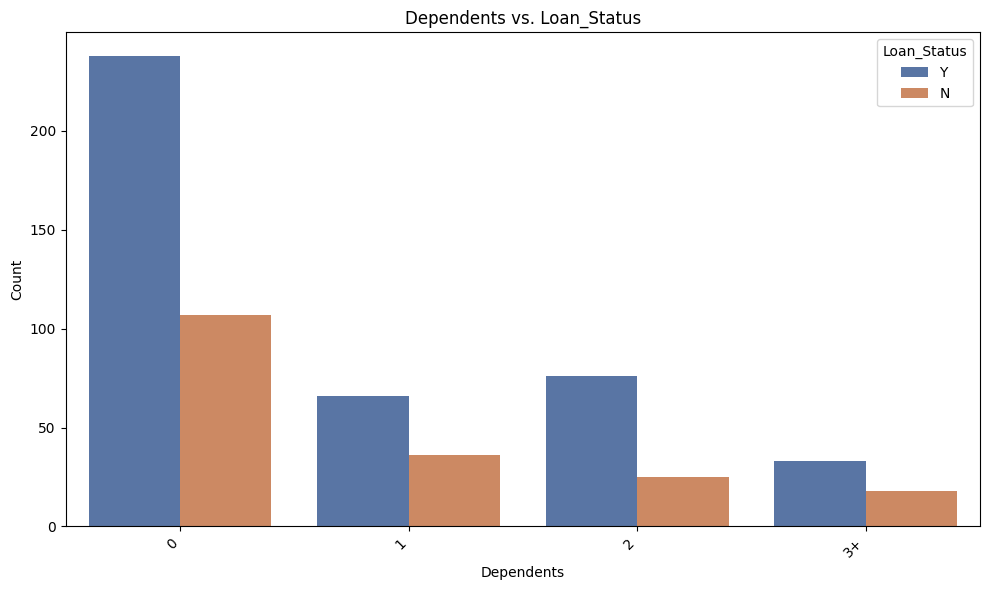

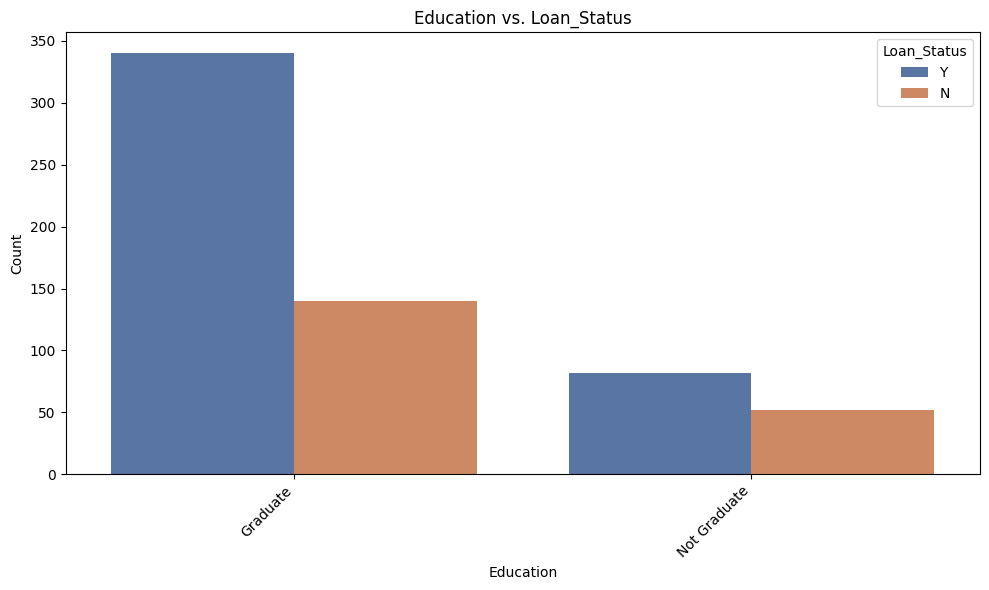

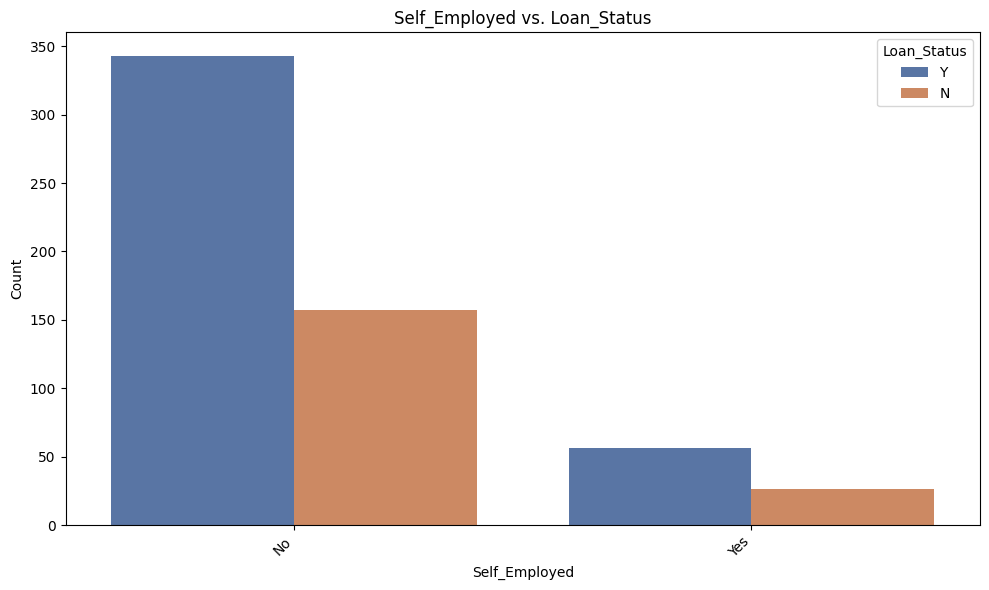

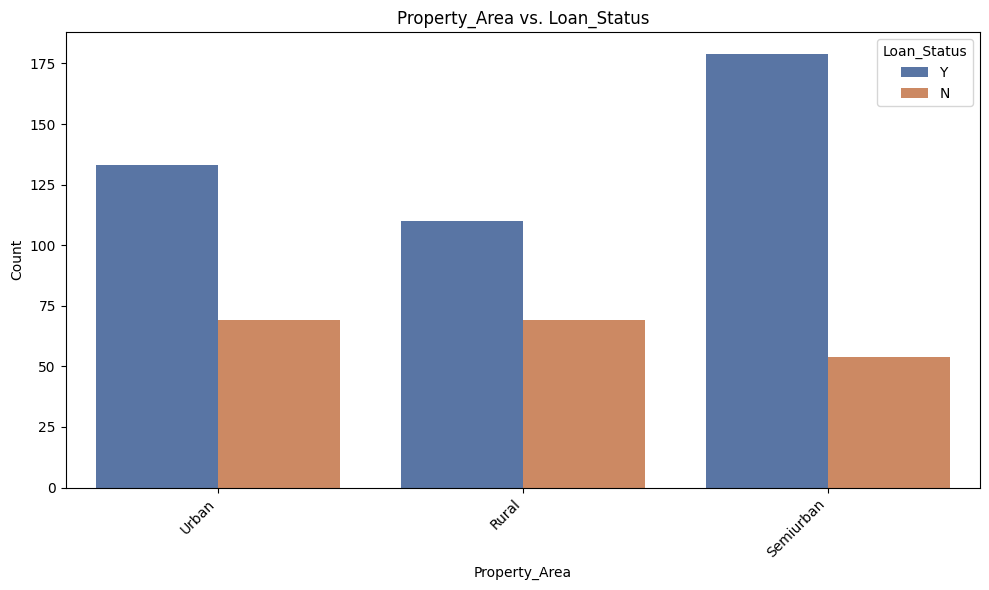

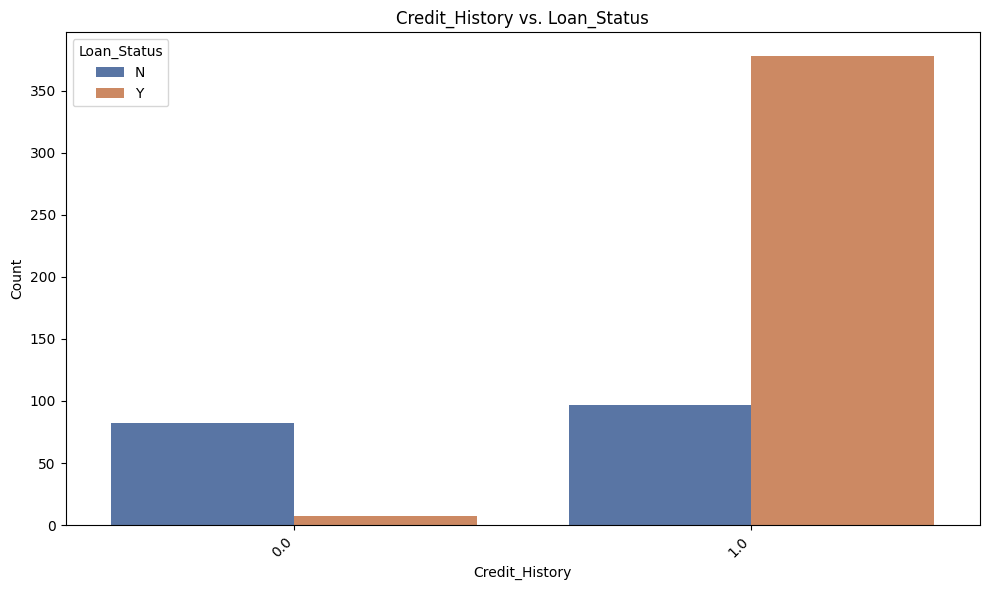

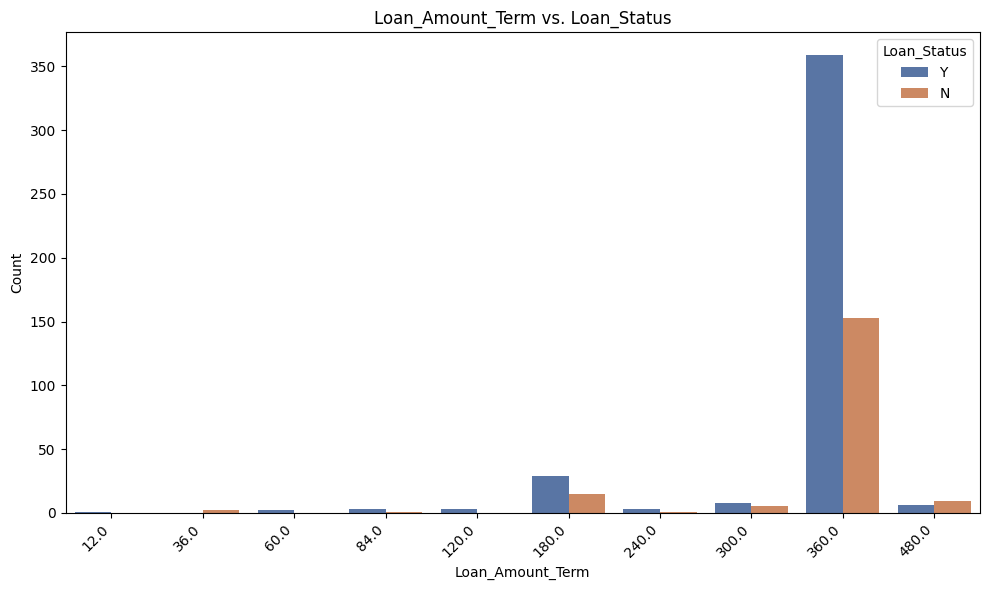


--- Numerical Features (Binned) vs. Loan_Status ---



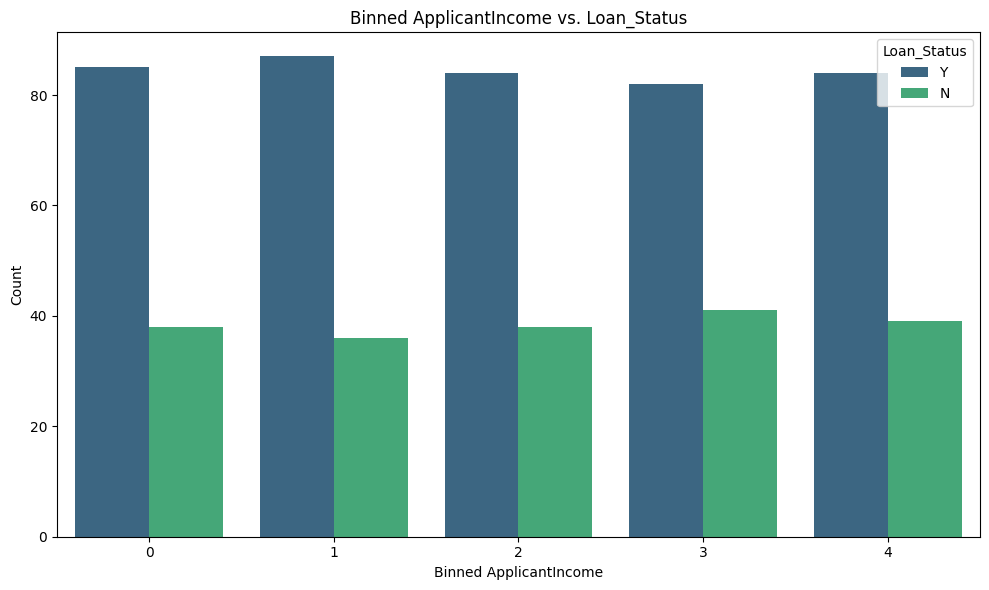

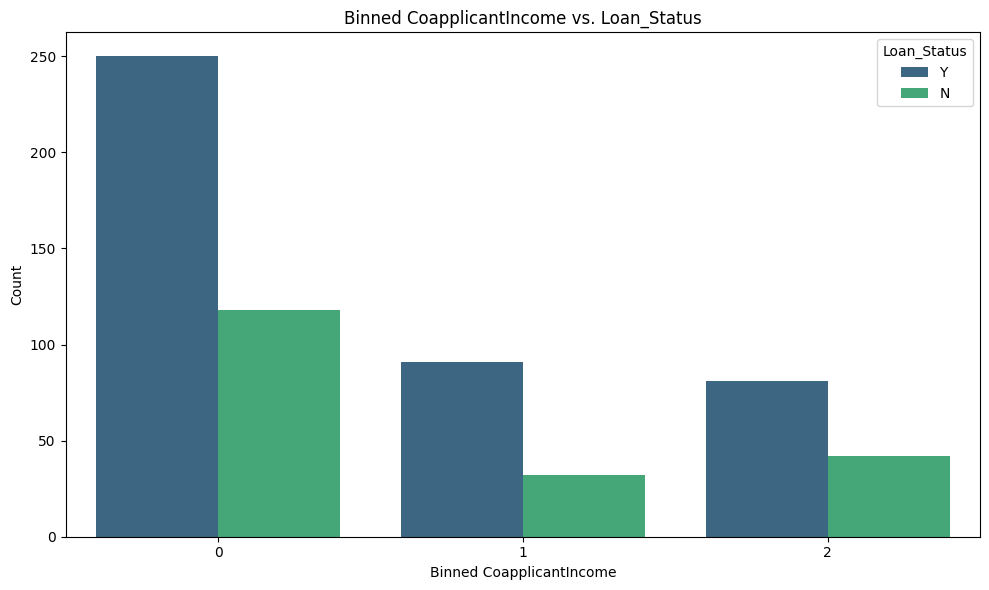

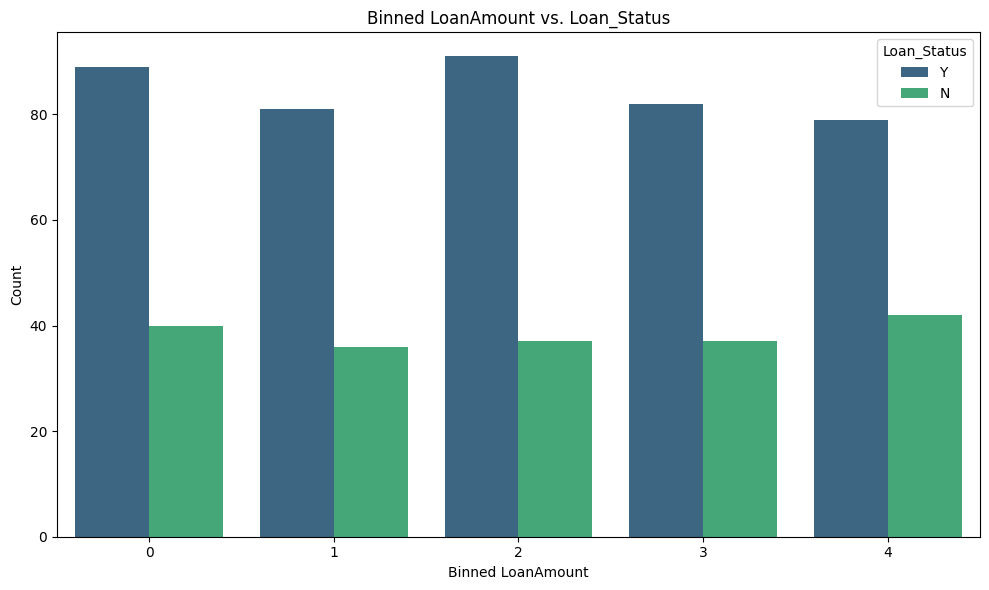

In [ ]:
print("\n--- Categorical Features vs. Loan_Status ---\n")
# Identify categorical columns, explicitly adding 'Credit_History' and 'Loan_Amount_Term'
categorical_features = train.select_dtypes(include='object').columns.tolist()
if 'Credit_History' not in categorical_features:
    categorical_features.append('Credit_History')
if 'Loan_Amount_Term' not in categorical_features:
    categorical_features.append('Loan_Amount_Term')

# Remove 'Loan_ID' and 'Loan_Status' if present, as they are an identifier and target variable, respectively
if 'Loan_ID' in categorical_features:
    categorical_features.remove('Loan_ID')
if 'Loan_Status' in categorical_features:
    categorical_features.remove('Loan_Status')

for col in categorical_features:
    plt.figure(figsize=(10, 6))
    sns.countplot(x=col, hue='Loan_Status', data=train, palette='deep')
    plt.title(f'{col} vs. Loan_Status')
    plt.xlabel(col)
    plt.ylabel('Count')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

print("\n--- Numerical Features (Binned) vs. Loan_Status ---\n")
# Identify numerical columns, excluding those already treated as categorical
numerical_features = train.select_dtypes(include=np.number).columns.tolist()
numerical_features = [col for col in numerical_features if col not in ['Credit_History', 'Loan_Amount_Term']]

for col in numerical_features:
    plt.figure(figsize=(10, 6))

    # Handle missing values by filling with the median for binning
    temp_col = train[col].fillna(train[col].median())

    # Optimal binning using pd.qcut for quantile-based bins
    # Using 5 bins, you can adjust n_bins as needed
    # labels=False assigns integer labels to bins, making them easier to plot
    # duplicates='drop' handles cases where some quantiles might be identical
    train[f'{col}_binned'] = pd.qcut(temp_col, q=5, duplicates='drop', labels=False)

    sns.countplot(x=f'{col}_binned', hue='Loan_Status', data=train, palette='viridis')
    plt.title(f'Binned {col} vs. Loan_Status')
    plt.xlabel(f'Binned {col}')
    plt.ylabel('Count')
    plt.tight_layout()
    plt.show()

    # Drop the temporary binned column to avoid polluting the original DataFrame
    train.drop(columns=[f'{col}_binned'], inplace=True, errors='ignore')

* If married means more chance of getting loan
* If 0 dependents means more chance of getting loan
* If graduate means more chance of getting loan
* If from semiurban area means chance of getting loan is more
* If Credit history is good then chance of getting loan is more
* If loan term is 480 then chance of getting rejected is more
* if loan amount is more then chance of getting rejected is more




/tmp/ipykernel_674/3271499787.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='ApplicantIncome_binned', y='LoanAmount', data=income_loan_amount, palette='viridis')


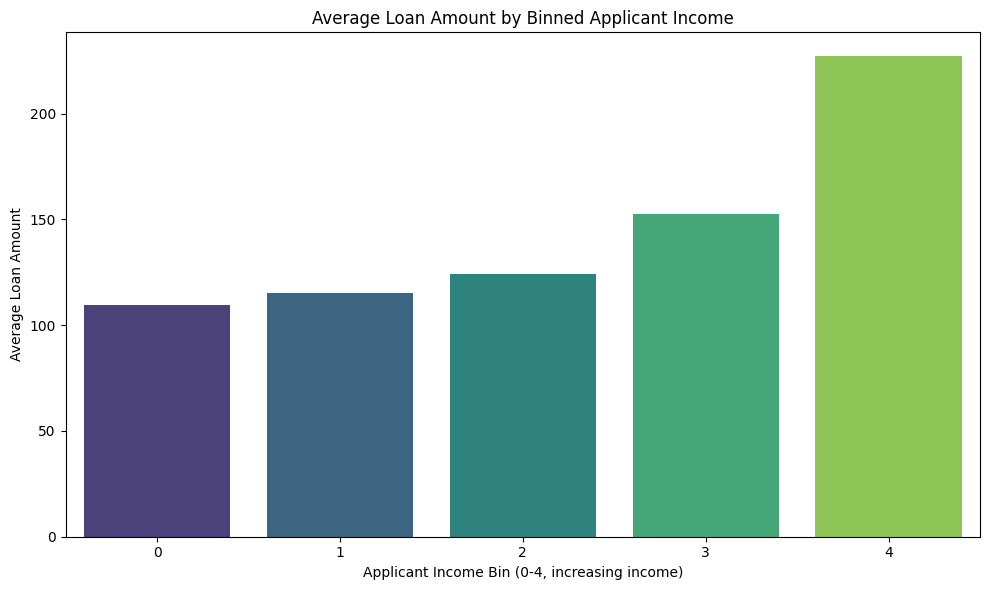

In [ ]:
# Handle missing values for ApplicantIncome and LoanAmount
train_temp = train.copy()
train_temp['ApplicantIncome'] = train_temp['ApplicantIncome'].fillna(train_temp['ApplicantIncome'].median())
train_temp['LoanAmount'] = train_temp['LoanAmount'].fillna(train_temp['LoanAmount'].median())

# Bin 'ApplicantIncome' into 5 quantiles
train_temp['ApplicantIncome_binned'] = pd.qcut(train_temp['ApplicantIncome'], q=5, duplicates='drop', labels=False)

# Calculate the mean LoanAmount for each ApplicantIncome bin
income_loan_amount = train_temp.groupby('ApplicantIncome_binned')['LoanAmount'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(x='ApplicantIncome_binned', y='LoanAmount', data=income_loan_amount, palette='viridis')
plt.title('Average Loan Amount by Binned Applicant Income')
plt.xlabel('Applicant Income Bin (0-4, increasing income)')
plt.ylabel('Average Loan Amount')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Clean up the temporary binned column (optional, as we used a copy of the dataframe)
# del train_temp['ApplicantIncome_binned']

There is a positive corelation between loan amount and applicant income

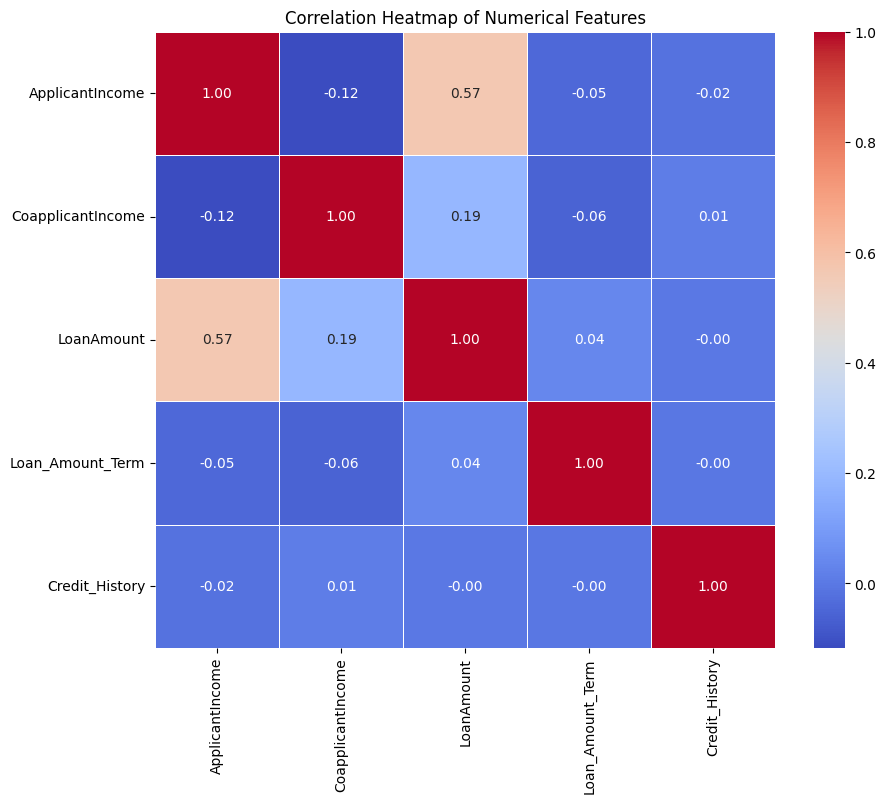

In [ ]:
numerical_cols_for_corr = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History']

# Create a temporary DataFrame for correlation calculation, filling missing numerical values with median
train_corr = train[numerical_cols_for_corr].copy()
for col in numerical_cols_for_corr:
    train_corr[col] = train_corr[col].fillna(train_corr[col].median())

# Calculate the correlation matrix
corr_matrix = train_corr.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f", linewidths=.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.show()

# Feature engineering

In [ ]:
train['Total_Income']=train['ApplicantIncome']+train['CoapplicantIncome']
test['Total_Income']=test['ApplicantIncome']+test['CoapplicantIncome']

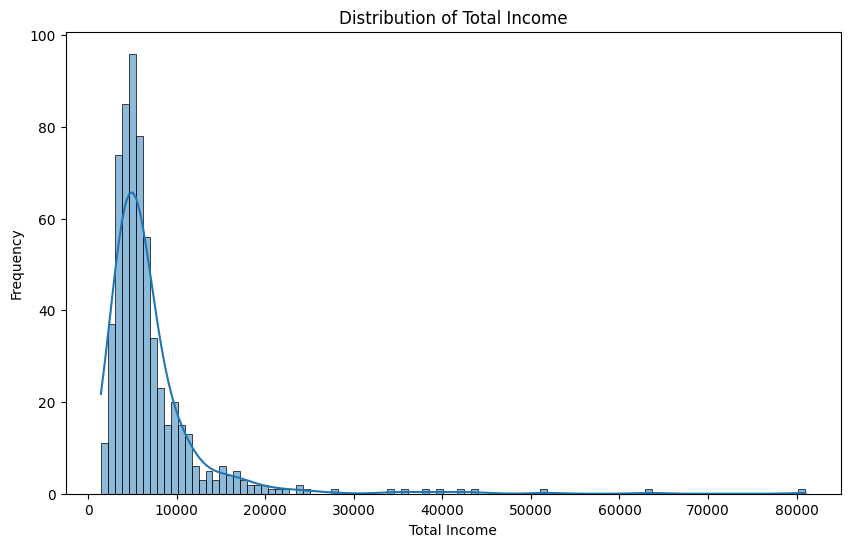

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train['Total_Income'], kde=True)
plt.title('Distribution of Total Income')
plt.xlabel('Total Income')
plt.ylabel('Frequency')
plt.show()

In [ ]:
train['Total_Income_log'] = np.log(train['Total_Income'])
test['Total_Income_log'] = np.log(test['Total_Income'])

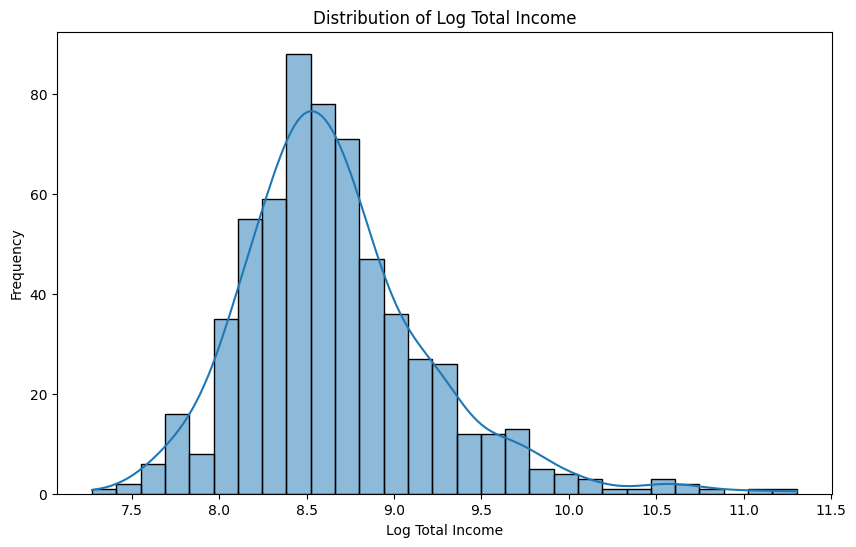

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train['Total_Income_log'], kde=True)
plt.title('Distribution of Log Total Income')
plt.xlabel('Log Total Income')
plt.ylabel('Frequency')
plt.show()

In [ ]:
train['EMI']=train['LoanAmount']/train['Loan_Amount_Term']
test['EMI']=test['LoanAmount']/test['Loan_Amount_Term']


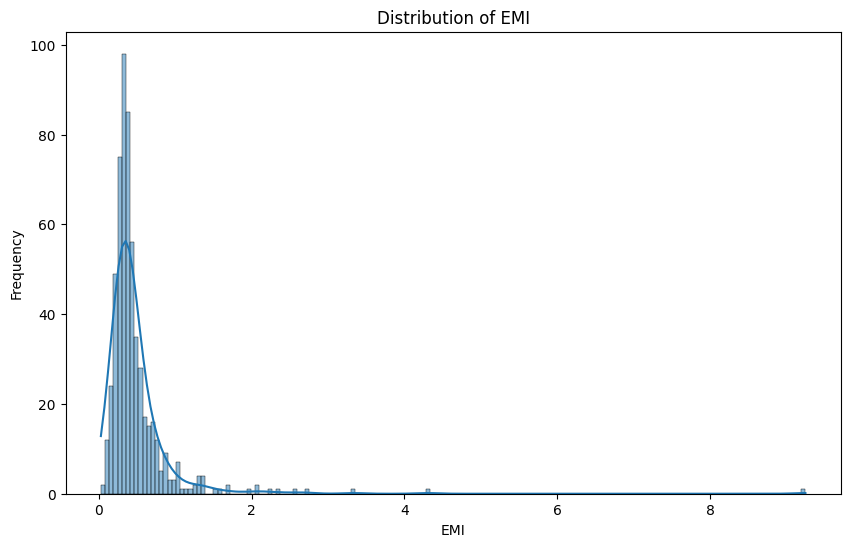

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train['EMI'], kde=True)
plt.title('Distribution of EMI')
plt.xlabel('EMI')
plt.ylabel('Frequency')
plt.show()

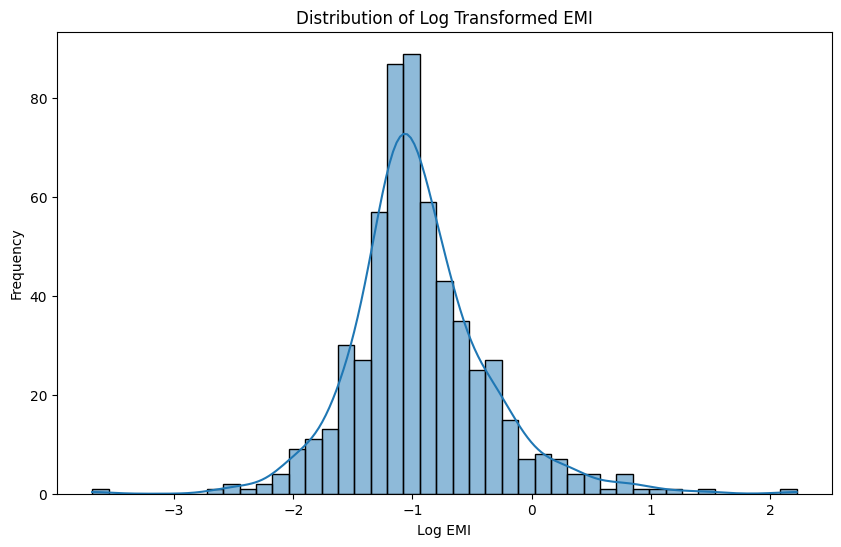

In [ ]:
train['EMI_log'] = np.log(train['EMI'])
test['EMI_log'] = np.log(test['EMI'])

plt.figure(figsize=(10, 6))
sns.histplot(train['EMI_log'], kde=True)
plt.title('Distribution of Log Transformed EMI')
plt.xlabel('Log EMI')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_674/4221231834.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(train['Balance Income']);


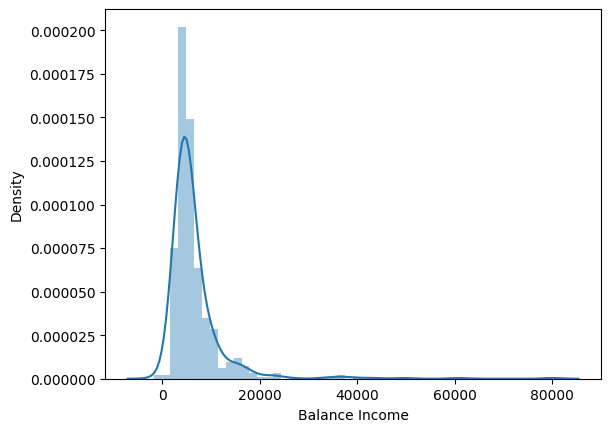

In [ ]:
train['Balance Income']=train['Total_Income']-(train['EMI']*1000)
# Multiply with 1000 to make the units equal
test['Balance Income']=test['Total_Income']-(test['EMI']*1000)
sns.distplot(train['Balance Income']);

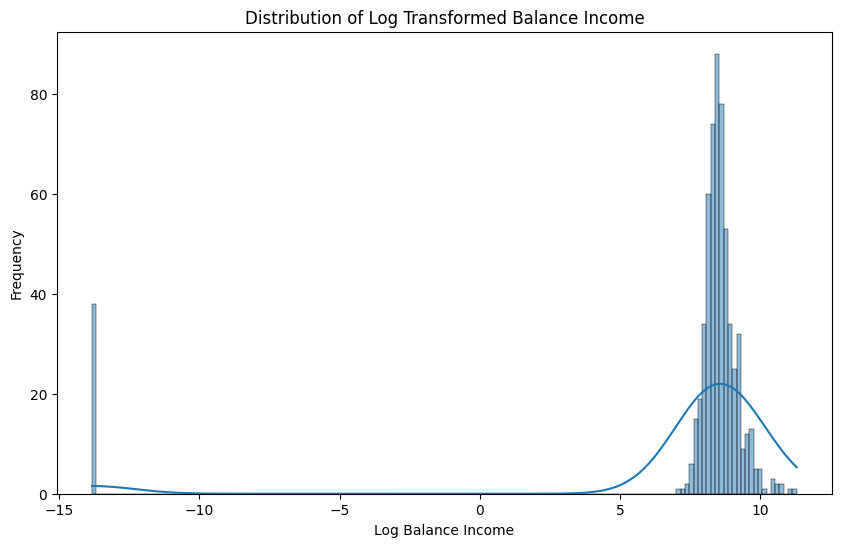

In [ ]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

epsilon = 1e-6 # A small positive constant to handle non-positive values
train['Balance_Income_log'] = np.log(train['Balance Income'].apply(lambda x: x if x > 0 else epsilon))
test['Balance_Income_log'] = np.log(test['Balance Income'].apply(lambda x: x if x > 0 else epsilon))

plt.figure(figsize=(10, 6))
sns.histplot(train['Balance_Income_log'], kde=True)
plt.title('Distribution of Log Transformed Balance Income')
plt.xlabel('Log Balance Income')
plt.ylabel('Frequency')
plt.show()

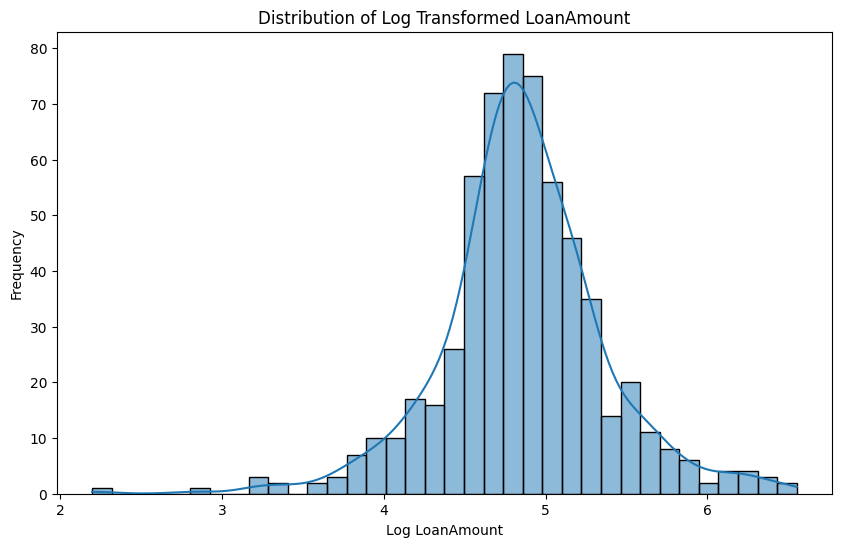

In [ ]:
train['LoanAmount_log'] = np.log(train['LoanAmount'])
test['LoanAmount_log'] = np.log(test['LoanAmount'])

plt.figure(figsize=(10, 6))
sns.histplot(train['LoanAmount_log'], kde=True)
plt.title('Distribution of Log Transformed LoanAmount')
plt.xlabel('Log LoanAmount')
plt.ylabel('Frequency')
plt.show()

In [ ]:
train['LoanToIncome'] = train['LoanAmount'] / train['Total_Income']
test['LoanToIncome'] = test['LoanAmount'] / test['Total_Income']

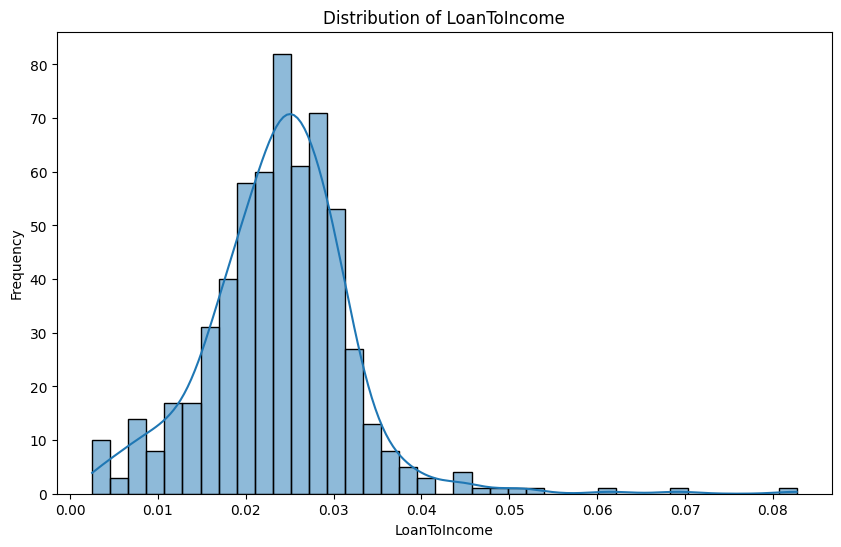

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(train['LoanToIncome'], kde=True)
plt.title('Distribution of LoanToIncome')
plt.xlabel('LoanToIncome')
plt.ylabel('Frequency')
plt.show()

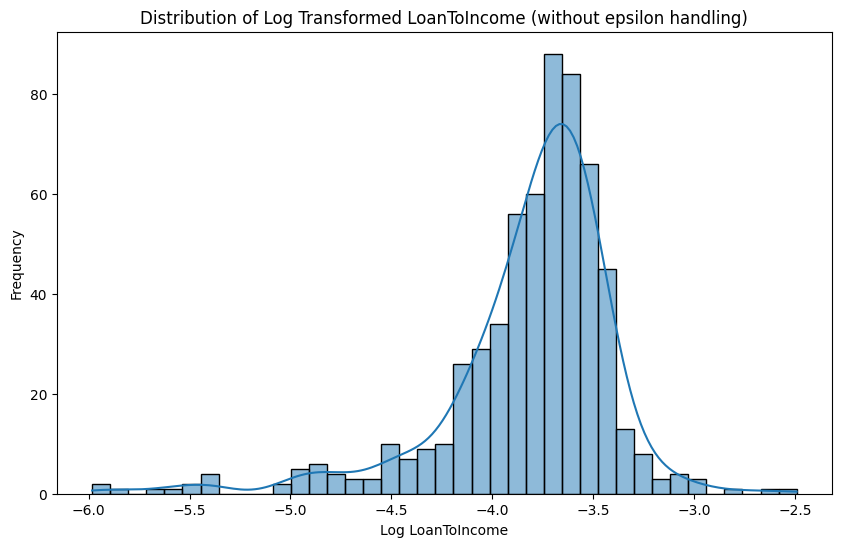

In [ ]:
train['LoanToIncome_log'] = np.log(train['LoanToIncome'])
test['LoanToIncome_log'] = np.log(test['LoanToIncome'])

plt.figure(figsize=(10, 6))
sns.histplot(train['LoanToIncome_log'], kde=True)
plt.title('Distribution of Log Transformed LoanToIncome (without epsilon handling)')
plt.xlabel('Log LoanToIncome')
plt.ylabel('Frequency')
plt.show()

In [ ]:
train["HasCoapplicant"] = (train["CoapplicantIncome"] > 0).astype(int)
test["HasCoapplicant"] = (test["CoapplicantIncome"] > 0).astype(int)

Missing value founding

In [ ]:
train.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


Drop unwanted rows

In [ ]:
columns_to_drop = [
    'Loan_ID',
    'ApplicantIncome',
    'CoapplicantIncome',
    'Total_Income',
    'EMI',
    'Balance Income',
    'LoanAmount',
    'LoanToIncome'
]

# Drop columns from train DataFrame
train = train.drop(columns=columns_to_drop, axis=1)

# Drop columns from test DataFrame
test = test.drop(columns=columns_to_drop, axis=1)

print("Columns dropped successfully from train and test DataFrames.")
print("Remaining columns in train:", train.columns.tolist())
print("Remaining columns in test:", test.columns.tolist())

Columns dropped successfully from train and test DataFrames.
Remaining columns in train: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status', 'Total_Income_log', 'EMI_log', 'Balance_Income_log', 'LoanAmount_log', 'LoanToIncome_log', 'HasCoapplicant']
Remaining columns in test: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Total_Income_log', 'EMI_log', 'Balance_Income_log', 'LoanAmount_log', 'LoanToIncome_log', 'HasCoapplicant']


Here i am going to handle missing that i though i should

In [ ]:
train.isnull().sum()

,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
Loan_Amount_Term,14
Credit_History,50
Property_Area,0
Loan_Status,0
Total_Income_log,0


I am going to handle missing value in gender by imputing knn method

Again i am going to use knn imputer for missing values in married features


I am going to replace mode value for dependents feature


For Self_Employed missing value should be replaced with new number

For Loan amount term missing value should be replaced with knn imputer

For credit history create new number for feature

For Emi log also knn imputer

For loan amount log replace it with knn imputer

For loanTolincome replace it with knn imputer

In [ ]:
train

,Gender,Married,Dependents,Education,Self_Employed,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status,Total_Income_log,EMI_log,Balance_Income_log,LoanAmount_log,LoanToIncome_log,HasCoapplicant
0,Male,No,0,Graduate,No,360.0,1.0,Urban,Y,8.674026,NaN,-13.815511,NaN,NaN,0
1,Male,Yes,1,Graduate,No,360.0,1.0,Rural,N,8.714568,-1.034074,8.654421,4.852030,-3.862537,1
2,Male,Yes,0,Graduate,Yes,360.0,1.0,Urban,Y,8.006368,-1.696449,7.943309,4.189655,-3.816713,0
3,Male,Yes,0,Not Graduate,No,360.0,1.0,Urban,Y,8.505323,-1.098612,8.435477,4.787492,-3.717831,1
4,Male,No,0,Graduate,No,360.0,1.0,Urban,Y,8.699515,-0.937344,8.632009,4.948760,-3.750755,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,360.0,1.0,Rural,Y,7.972466,-1.623424,7.902035,4.262680,-3.709786,0
610,Male,Yes,3+,Graduate,No,180.0,1.0,Rural,Y,8.320205,-1.504077,8.264564,3.688879,-4.631325,0
611,Male,Yes,1,Graduate,No,360.0,1.0,Urban,Y,9.025456,-0.352715,8.937116,5.533389,-3.492066,1
612,Male,Yes,2,Graduate,No,360.0,1.0,Urban,Y,8.933664,-0.654995,8.862704,5.231109,-3.702556,0


In [ ]:
# Apply encodings only to the existing train and test DataFrames.

# Ordinal Encoding for 'Dependents'
for df in [train, test]:
    if 'Dependents' in df.columns:
        df['Dependents'] = df['Dependents'].replace('3+', '3')
        df['Dependents'] = pd.to_numeric(df['Dependents'], errors='coerce')

# Label Encoding for 'Loan_Status' (only in train)
if 'Loan_Status' in train.columns:
    train['Loan_Status'] = train['Loan_Status'].map({'Y': 1, 'N': 0})

# One-Hot Encoding for specified categorical features
one_hot_cols = ['Gender', 'Married', 'Education', 'Self_Employed', 'Credit_History', 'Property_Area']

# Process train DataFrame
current_one_hot_cols_train = [col for col in one_hot_cols if col in train.columns]
# Convert Credit_History to object type before one-hot encoding if it's numerical (0.0/1.0)
if 'Credit_History' in current_one_hot_cols_train and pd.api.types.is_numeric_dtype(train['Credit_History']):
    train['Credit_History'] = train['Credit_History'].astype(object)
train = pd.get_dummies(train, columns=current_one_hot_cols_train, drop_first=True)

# Process test DataFrame
current_one_hot_cols_test = [col for col in one_hot_cols if col in test.columns]
# Convert Credit_History to object type before one-hot encoding if it's numerical (0.0/1.0)
if 'Credit_History' in current_one_hot_cols_test and pd.api.types.is_numeric_dtype(test['Credit_History']):
    test['Credit_History'] = test['Credit_History'].astype(object)
test = pd.get_dummies(test, columns=current_one_hot_cols_test, drop_first=True)

# Convert boolean columns (from one-hot encoding) to int (0 or 1)
for col in train.select_dtypes(include='bool').columns:
    train[col] = train[col].astype(int)
for col in test.select_dtypes(include='bool').columns:
    test[col] = test[col].astype(int)



Encodings complete.

Train DataFrame head after encodings:
   Dependents  Loan_Amount_Term  Loan_Status  Total_Income_log   EMI_log  \
0         0.0             360.0          NaN          8.674026       NaN   
1         1.0             360.0          NaN          8.714568 -1.034074   
2         0.0             360.0          NaN          8.006368 -1.696449   
3         0.0             360.0          NaN          8.505323 -1.098612   
4         0.0             360.0          NaN          8.699515 -0.937344   

   Balance_Income_log  LoanAmount_log  LoanToIncome_log  HasCoapplicant  \
0          -13.815511             NaN               NaN               0   
1            8.654421        4.852030         -3.862537               1   
2            7.943309        4.189655         -3.816713               0   
3            8.435477        4.787492         -3.717831               1   
4            8.632009        4.948760         -3.750755               0   

   Gender_Male  Married_Yes  Educ

In [ ]:
train

,Dependents,Loan_Amount_Term,Loan_Status,Total_Income_log,EMI_log,Balance_Income_log,LoanAmount_log,LoanToIncome_log,HasCoapplicant,Gender_Male,Married_Yes,Education_Not Graduate,Self_Employed_Yes,Credit_History_1.0,Property_Area_Semiurban,Property_Area_Urban
0,0.0,360.0,NaN,8.674026,NaN,-13.815511,NaN,NaN,0,1,0,0,0,1,0,1
1,1.0,360.0,NaN,8.714568,-1.034074,8.654421,4.852030,-3.862537,1,1,1,0,0,1,0,0
2,0.0,360.0,NaN,8.006368,-1.696449,7.943309,4.189655,-3.816713,0,1,1,0,1,1,0,1
3,0.0,360.0,NaN,8.505323,-1.098612,8.435477,4.787492,-3.717831,1,1,1,1,0,1,0,1
4,0.0,360.0,NaN,8.699515,-0.937344,8.632009,4.948760,-3.750755,0,1,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,0.0,360.0,NaN,7.972466,-1.623424,7.902035,4.262680,-3.709786,0,0,0,0,0,1,0,0
610,3.0,180.0,NaN,8.320205,-1.504077,8.264564,3.688879,-4.631325,0,1,1,0,0,1,0,0
611,1.0,360.0,NaN,9.025456,-0.352715,8.937116,5.533389,-3.492066,1,1,1,0,0,1,0,1
612,2.0,360.0,NaN,8.933664,-0.654995,8.862704,5.231109,-3.702556,0,1,1,0,0,1,0,1


Now i am ready to build models

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 1. Correct Loan_Status in train DataFrame by re-mapping from train_original
# The 'Loan_Status' column in the current 'train' DataFrame appears to have NaNs after previous steps.
# We will use train_original to get the correct target variable.
y_train = train_original['Loan_Status'].map({'Y': 1, 'N': 0})

# X_train should be derived from the current 'train' DataFrame, dropping 'Loan_Status'
X_train = train.drop('Loan_Status', axis=1)

# X_test is already prepared from the current 'test' DataFrame
X_test = test.copy()

# Ensure X_train and X_test have the same columns before preprocessing, to prevent issues during prediction
# This step is critical if one-hot encoding might have produced different columns due to different unique values
common_cols = list(set(X_train.columns) & set(X_test.columns))
X_train = X_train[common_cols]
X_test = X_test[common_cols]

# Align columns - crucial for consistent feature sets
X_train = X_train.reindex(columns = sorted(X_train.columns))
X_test = X_test.reindex(columns = sorted(X_test.columns))

# Identify columns for imputation based on remaining NaNs in X_train (as per kernel state)
# Based on `train.isnull().sum()` from kernel state:
# Dependents (Mode Imputer), Loan_Amount_Term, EMI_log, LoanAmount_log, LoanToIncome_log (KNN Imputer)

# Columns for KNN Imputer (numerical and to be scaled)
numerical_knn_cols = ['Loan_Amount_Term', 'EMI_log', 'LoanAmount_log', 'LoanToIncome_log']

# Column for Mode Imputer (ordinal)
ordinal_mode_cols = ['Dependents']

# All other numerical columns (including one-hot encoded ones) for scaling only
# These columns do not show NaNs in the current `train` variable's isnull().sum()
remaining_numerical_cols = [col for col in X_train.columns if col not in numerical_knn_cols + ordinal_mode_cols]

# Create preprocessing pipelines for different column groups

# Pipeline for numerical features that require KNN imputation and scaling
numerical_transformer_knn = Pipeline(steps=[
    ('knn_imputer', KNNImputer(n_neighbors=5)),
    ('scaler', StandardScaler())
])

# Pipeline for ordinal features that require mode imputation
ordinal_transformer_mode = Pipeline(steps=[
    ('mode_imputer', SimpleImputer(strategy='most_frequent'))
])

# Pipeline for other numerical features that only require scaling (already handled NaNs implicitly)
scaler_only_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

# Create a ColumnTransformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num_knn', numerical_transformer_knn, numerical_knn_cols),
        ('ord_mode', ordinal_transformer_mode, ordinal_mode_cols),
        ('scale_others', scaler_only_transformer, remaining_numerical_cols)
    ],
    remainder='drop' # Drop any unhandled columns (e.g., if any column type was missed)
)

# Define the Logistic Regression model pipeline
model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('classifier', LogisticRegression(class_weight='balanced', solver='liblinear', random_state=42)) # Using liblinear for robustness
])

# Define parameter grid for GridSearchCV for Logistic Regression
param_grid = {
    'classifier__C': [0.01, 0.1, 1, 10, 100], # Inverse of regularization strength
    'classifier__penalty': ['l1', 'l2'] # Regularization type (liblinear supports both)
}

# Setup Stratified K-Fold Cross-Validation
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Create GridSearchCV object
grid_search = GridSearchCV(
    model_pipeline,
    param_grid,
    cv=cv,
    scoring='roc_auc', # Optimizing for ROC AUC
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Train the model
print("Starting GridSearchCV for Logistic Regression...")
grid_search.fit(X_train, y_train)
print("GridSearchCV for Logistic Regression complete.")

# Best Logistic Regression model and its parameters
best_model = grid_search.best_estimator_
print(f"\nBest Logistic Regression parameters found: {grid_search.best_params_}")
print(f"Best Logistic Regression ROC AUC score (Cross-Validation): {grid_search.best_score_:.4f}")

# Evaluate on the training set with the best model
y_pred_train = best_model.predict(X_train)
y_pred_proba_train = best_model.predict_proba(X_train)[:, 1]

print("\n--- Training Set Metrics (from best Logistic Regression model) ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_proba_train):.4f}")
print("\nClassification Report:\n", classification_report(y_train, y_pred_train))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train))

# Predict on the test set with the best model
y_test_pred = best_model.predict(X_test)
y_test_pred_proba = best_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Predictions (First 5 from Logistic Regression) ---")
print(y_test_pred[:5])
print("\nTest Set Prediction Probabilities (First 5 for positive class from Logistic Regression) ---")
print(y_test_pred_proba[:5])

Starting GridSearchCV for Logistic Regression...
Fitting 10 folds for each of 10 candidates, totalling 100 fits
GridSearchCV for Logistic Regression complete.

Best Logistic Regression parameters found: {'classifier__C': 0.1, 'classifier__penalty': 'l1'}
Best Logistic Regression ROC AUC score (Cross-Validation): 0.7466

--- Training Set Metrics (from best Logistic Regression model) ---
Accuracy: 0.7590
Precision: 0.8044
Recall: 0.8578
F1-Score: 0.8303
ROC AUC: 0.7730

Classification Report:
               precision    recall  f1-score   support

           0       0.63      0.54      0.58       192
           1       0.80      0.86      0.83       422

    accuracy                           0.76       614
   macro avg       0.72      0.70      0.71       614
weighted avg       0.75      0.76      0.75       614


Confusion Matrix:
 [[104  88]
 [ 60 362]]

--- Test Set Predictions (First 5 from Logistic Regression) ---
[1 1 1 0 0]

Test Set Prediction Probabilities (First 5 for positive

In [ ]:
from sklearn.svm import SVC

# Define the SVM model pipeline, reusing the preprocessor from the previous cell
svm_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor defined previously
    ('classifier', SVC(class_weight='balanced', probability=True, random_state=42)) # probability=True for predict_proba
])

# Define parameter grid for GridSearchCV for SVC
svm_param_grid = {
    'classifier__C': [0.1, 1, 10], # Regularization parameter
    'classifier__kernel': ['linear', 'rbf'], # Kernel type
    'classifier__gamma': ['scale', 'auto'] # Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.
}

# Setup Stratified K-Fold Cross-Validation (re-use cv from previous cell)
cv_svm = cv # Re-using the StratifiedKFold instance named 'cv'

# Create GridSearchCV object for SVM
svm_grid_search = GridSearchCV(
    svm_model_pipeline,
    svm_param_grid,
    cv=cv_svm,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# Train the SVM model
print("Starting GridSearchCV for SVM...")
svm_grid_search.fit(X_train, y_train)
print("GridSearchCV for SVM complete.")

# Best SVM model and its parameters
best_svm_model = svm_grid_search.best_estimator_
print(f"\nBest SVM parameters found: {svm_grid_search.best_params_}")
print(f"Best SVM ROC AUC score (Cross-Validation): {svm_grid_search.best_score_:.4f}")

# Evaluate on the training set with the best SVM model
y_pred_train_svm = best_svm_model.predict(X_train)
y_pred_proba_train_svm = best_svm_model.predict_proba(X_train)[:, 1]

print("\n--- Training Set Metrics (from best SVM model) ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train_svm):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_svm):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_svm):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_svm):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_proba_train_svm):.4f}")
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_svm))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_svm))

# Predict on the test set with the best SVM model
y_test_pred_svm = best_svm_model.predict(X_test)
y_test_pred_proba_svm = best_svm_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Predictions (First 5 from SVM) ---")
print(y_test_pred_svm[:5])
print("\nTest Set Prediction Probabilities (First 5 for positive class from SVM) ---")
print(y_test_pred_proba_svm[:5])

Starting GridSearchCV for SVM...
Fitting 10 folds for each of 12 candidates, totalling 120 fits
GridSearchCV for SVM complete.

Best SVM parameters found: {'classifier__C': 0.1, 'classifier__gamma': 'scale', 'classifier__kernel': 'rbf'}
Best SVM ROC AUC score (Cross-Validation): 0.7394

--- Training Set Metrics (from best SVM model) ---
Accuracy: 0.7199
Precision: 0.8342
Recall: 0.7393
F1-Score: 0.7839
ROC AUC: 0.7878

Classification Report:
               precision    recall  f1-score   support

           0       0.54      0.68      0.60       192
           1       0.83      0.74      0.78       422

    accuracy                           0.72       614
   macro avg       0.69      0.71      0.69       614
weighted avg       0.74      0.72      0.73       614


Confusion Matrix:
 [[130  62]
 [110 312]]

--- Test Set Predictions (First 5 from SVM) ---
[1 1 1 0 0]

Test Set Prediction Probabilities (First 5 for positive class from SVM) ---
[0.8678121  0.916336   0.87636477 0.42221795 

In [ ]:
from sklearn.tree import DecisionTreeClassifier

# Define the Decision Tree model pipeline, reusing the preprocessor
dt_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor defined previously
    ('classifier', DecisionTreeClassifier(class_weight='balanced', random_state=42))
])

# Define parameter grid for GridSearchCV for Decision Tree
dt_param_grid = {
    'classifier__max_depth': [3, 5, 7, 10, None], # Max depth of the tree
    'classifier__min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'classifier__criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Setup Stratified K-Fold Cross-Validation (re-use cv from previous cell)
cv_dt = cv # Re-using the StratifiedKFold instance named 'cv'

# Create GridSearchCV object for Decision Tree
dt_grid_search = GridSearchCV(
    dt_model_pipeline,
    dt_param_grid,
    cv=cv_dt,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# Train the Decision Tree model
print("Starting GridSearchCV for Decision Tree...")
dt_grid_search.fit(X_train, y_train)
print("GridSearchCV for Decision Tree complete.")

# Best Decision Tree model and its parameters
best_dt_model = dt_grid_search.best_estimator_
print(f"\nBest Decision Tree parameters found: {dt_grid_search.best_params_}")
print(f"Best Decision Tree ROC AUC score (Cross-Validation): {dt_grid_search.best_score_:.4f}")

# Evaluate on the training set with the best Decision Tree model
y_pred_train_dt = best_dt_model.predict(X_train)
y_pred_proba_train_dt = best_dt_model.predict_proba(X_train)[:, 1]

print("\n--- Training Set Metrics (from best Decision Tree model) ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train_dt):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_dt):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_dt):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_dt):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_proba_train_dt):.4f}")
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_dt))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_dt))

# Predict on the test set with the best Decision Tree model
y_test_pred_dt = best_dt_model.predict(X_test)
y_test_pred_proba_dt = best_dt_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Predictions (First 5 from Decision Tree) ---")
print(y_test_pred_dt[:5])
print("\nTest Set Prediction Probabilities (First 5 for positive class from Decision Tree) ---")
print(y_test_pred_proba_dt[:5])

Starting GridSearchCV for Decision Tree...
Fitting 10 folds for each of 90 candidates, totalling 900 fits
GridSearchCV for Decision Tree complete.

Best Decision Tree parameters found: {'classifier__criterion': 'entropy', 'classifier__max_depth': 3, 'classifier__min_samples_leaf': 4, 'classifier__min_samples_split': 2}
Best Decision Tree ROC AUC score (Cross-Validation): 0.7438

--- Training Set Metrics (from best Decision Tree model) ---
Accuracy: 0.7834
Precision: 0.8148
Recall: 0.8863
F1-Score: 0.8490
ROC AUC: 0.7705

Classification Report:
               precision    recall  f1-score   support

           0       0.69      0.56      0.62       192
           1       0.81      0.89      0.85       422

    accuracy                           0.78       614
   macro avg       0.75      0.72      0.73       614
weighted avg       0.78      0.78      0.78       614


Confusion Matrix:
 [[107  85]
 [ 48 374]]

--- Test Set Predictions (First 5 from Decision Tree) ---
[1 1 1 0 1]

Test Se

In [ ]:
from sklearn.ensemble import RandomForestClassifier

# Define the Random Forest model pipeline, reusing the preprocessor
rf_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor defined previously
    ('classifier', RandomForestClassifier(class_weight='balanced', random_state=42))
])

# Define parameter grid for GridSearchCV for Random Forest
rf_param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of trees in the forest
    'classifier__max_depth': [5, 10, None], # Max depth of the tree
    'classifier__min_samples_split': [2, 5, 10], # Minimum number of samples required to split an internal node
    'classifier__min_samples_leaf': [1, 2, 4], # Minimum number of samples required to be at a leaf node
    'classifier__criterion': ['gini', 'entropy'] # Function to measure the quality of a split
}

# Setup Stratified K-Fold Cross-Validation (re-use cv from previous cell)
cv_rf = cv # Re-using the StratifiedKFold instance named 'cv'

# Create GridSearchCV object for Random Forest
rf_grid_search = GridSearchCV(
    rf_model_pipeline,
    rf_param_grid,
    cv=cv_rf,
    scoring='roc_auc',
    verbose=1,
    n_jobs=-1
)

# Train the Random Forest model
print("Starting GridSearchCV for Random Forest...")
rf_grid_search.fit(X_train, y_train)
print("GridSearchCV for Random Forest complete.")

# Best Random Forest model and its parameters
best_rf_model = rf_grid_search.best_estimator_
print(f"\nBest Random Forest parameters found: {rf_grid_search.best_params_}")
print(f"Best Random Forest ROC AUC score (Cross-Validation): {rf_grid_search.best_score_:.4f}")

# Evaluate on the training set with the best Random Forest model
y_pred_train_rf = best_rf_model.predict(X_train)
y_pred_proba_train_rf = best_rf_model.predict_proba(X_train)[:, 1]

print("\n--- Training Set Metrics (from best Random Forest model) ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train_rf):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_rf):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_rf):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_rf):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_proba_train_rf):.4f}")
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_rf))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_rf))

# Predict on the test set with the best Random Forest model
y_test_pred_rf = best_rf_model.predict(X_test)
y_test_pred_proba_rf = best_rf_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Predictions (First 5 from Random Forest) ---")
print(y_test_pred_rf[:5])
print("\nTest Set Prediction Probabilities (First 5 for positive class from Random Forest) ---")
print(y_test_pred_proba_rf[:5])

Starting GridSearchCV for Random Forest...
Fitting 10 folds for each of 162 candidates, totalling 1620 fits
GridSearchCV for Random Forest complete.

Best Random Forest parameters found: {'classifier__criterion': 'entropy', 'classifier__max_depth': 5, 'classifier__min_samples_leaf': 1, 'classifier__min_samples_split': 10, 'classifier__n_estimators': 300}
Best Random Forest ROC AUC score (Cross-Validation): 0.7518

--- Training Set Metrics (from best Random Forest model) ---
Accuracy: 0.8176
Precision: 0.8507
Recall: 0.8910
F1-Score: 0.8704
ROC AUC: 0.8896

Classification Report:
               precision    recall  f1-score   support

           0       0.73      0.66      0.69       192
           1       0.85      0.89      0.87       422

    accuracy                           0.82       614
   macro avg       0.79      0.77      0.78       614
weighted avg       0.81      0.82      0.81       614


Confusion Matrix:
 [[126  66]
 [ 46 376]]

--- Test Set Predictions (First 5 from Ran

In [ ]:
from xgboost import XGBClassifier

# Define the XGBoost model pipeline, reusing the preprocessor
xgb_model_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), # Use the preprocessor defined previously
    ('classifier', XGBClassifier(objective='binary:logistic', eval_metric='logloss', use_label_encoder=False, scale_pos_weight=(len(y_train) - y_train.sum()) / y_train.sum(), random_state=42)) # scale_pos_weight for class_weight='balanced'
])

# Define parameter grid for GridSearchCV for XGBoost
xgb_param_grid = {
    'classifier__n_estimators': [100, 200, 300], # Number of boosting rounds
    'classifier__max_depth': [3, 5, 7], # Maximum depth of a tree
    'classifier__learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage to prevent overfitting
    'classifier__subsample': [0.7, 0.8, 1.0], # Subsample ratio of the training instance
    'classifier__colsample_bytree': [0.7, 0.8, 1.0] # Subsample ratio of columns when constructing each tree
}

# Setup Stratified K-Fold Cross-Validation (re-use cv from previous cell)
cv_xgb = cv # Re-using the StratifiedKFold instance named 'cv'

# Create GridSearchCV object for XGBoost
xgb_grid_search = GridSearchCV(
    xgb_model_pipeline,
    xgb_param_grid,
    cv=cv_xgb,
    scoring='roc_auc', # Optimizing for ROC AUC
    verbose=1,
    n_jobs=-1 # Use all available cores
)

# Train the XGBoost model
print("Starting GridSearchCV for XGBoost...")
xgb_grid_search.fit(X_train, y_train)
print("GridSearchCV for XGBoost complete.")

# Best XGBoost model and its parameters
best_xgb_model = xgb_grid_search.best_estimator_
print(f"\nBest XGBoost parameters found: {xgb_grid_search.best_params_}")
print(f"Best XGBoost ROC AUC score (Cross-Validation): {xgb_grid_search.best_score_:.4f}")

# Evaluate on the training set with the best XGBoost model
y_pred_train_xgb = best_xgb_model.predict(X_train)
y_pred_proba_train_xgb = best_xgb_model.predict_proba(X_train)[:, 1]

print("\n--- Training Set Metrics (from best XGBoost model) ---")
print(f"Accuracy: {accuracy_score(y_train, y_pred_train_xgb):.4f}")
print(f"Precision: {precision_score(y_train, y_pred_train_xgb):.4f}")
print(f"Recall: {recall_score(y_train, y_pred_train_xgb):.4f}")
print(f"F1-Score: {f1_score(y_train, y_pred_train_xgb):.4f}")
print(f"ROC AUC: {roc_auc_score(y_train, y_pred_proba_train_xgb):.4f}")
print("\nClassification Report:\n", classification_report(y_train, y_pred_train_xgb))
print("\nConfusion Matrix:\n", confusion_matrix(y_train, y_pred_train_xgb))

# Predict on the test set with the best XGBoost model
y_test_pred_xgb = best_xgb_model.predict(X_test)
y_test_pred_proba_xgb = best_xgb_model.predict_proba(X_test)[:, 1]

print("\n--- Test Set Predictions (First 5 from XGBoost) ---")
print(y_test_pred_xgb[:5])
print("\nTest Set Prediction Probabilities (First 5 for positive class from XGBoost) ---")
print(y_test_pred_proba_xgb[:5])

Starting GridSearchCV for XGBoost...
Fitting 10 folds for each of 243 candidates, totalling 2430 fits
GridSearchCV for XGBoost complete.

Best XGBoost parameters found: {'classifier__colsample_bytree': 0.7, 'classifier__learning_rate': 0.01, 'classifier__max_depth': 3, 'classifier__n_estimators': 200, 'classifier__subsample': 0.7}
Best XGBoost ROC AUC score (Cross-Validation): 0.7551

--- Training Set Metrics (from best XGBoost model) ---
Accuracy: 0.8046
Precision: 0.8463
Recall: 0.8744
F1-Score: 0.8601
ROC AUC: 0.8531

Classification Report:
               precision    recall  f1-score   support

           0       0.70      0.65      0.68       192
           1       0.85      0.87      0.86       422

    accuracy                           0.80       614
   macro avg       0.77      0.76      0.77       614
weighted avg       0.80      0.80      0.80       614


Confusion Matrix:
 [[125  67]
 [ 53 369]]

--- Test Set Predictions (First 5 from XGBoost) ---
[1 1 1 0 0]

Test Set Pred

# Random Forest is the best model to build